In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_excel('https://raw.githubusercontent.com/sarah-yiyang/witOmni-1A-ai-studio/main/data/Online%20Retail.xlsx', header=0)

In [3]:
print(df.shape)

(541909, 8)


## Explore

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [31]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [32]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [33]:
#Quantity and unit price have negative minimum numbers, in this context negatives dont make sense

#Lets find out how many there are
print(f'Negative quantity rows: {(df['Quantity'] < 0).sum()}\nNegative unit price rows: {(df['UnitPrice'] < 0).sum()}\nZero unit price rows: {(df['UnitPrice'] == 0).sum()}')

Negative quantity rows: 10624
Negative unit price rows: 2
Zero unit price rows: 2515


## Clean dataset

#### Drop rows where unit price is 0

In [38]:
print(len(df[df['UnitPrice'] == 0]))

2515


In [39]:
#Remove all rows where unit price is 0 because it has no relevance to customer purchasing
df = df[df['UnitPrice'] > 0 ]

In [40]:
print(df.shape)

(539392, 8)


#### Drop rows where Quantity is negative

In [41]:
#Remove all rows where qu
df = df[df['Quantity'] >= 1]

In [42]:
print(df.shape)

(530104, 8)


#### Drop Null Values

In [43]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,132220
Country,0


In [44]:
#Will not be able to determine customer with null values so we will drop all rows where customer id is null
df = df.dropna()

In [45]:
print(df.shape)

(397884, 8)


## Detect Outliers

In [46]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,179.331775,NaN,22.097877,1713.141560


In [47]:
#There seems to be extreme outliers in quantity in unit price because the max is very far from the mean and median
print(df['Quantity'].median(), df['UnitPrice'].median())

6.0 1.95


In [48]:
# 2 rows are sitting around 80k while the rest gradually rise to 4.8k
df.sort_values('Quantity', ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,2011-11-02 11:24:00,0.32,16308.0,United Kingdom
291249,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,2011-08-04 18:06:00,1.45,12931.0,United Kingdom


In [49]:
cap = df['Quantity'].quantile(.999)
print(cap)

504.0


## RFM Analysis

In [50]:
#get a relative day for when dataset stopped collecting data to compare recency
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [51]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [52]:
rfm = df.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'), #unique invoices only
    Monetary = ('TotalPrice', 'sum')
)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [53]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [16]:
rfm.shape

(4338, 3)

In [54]:
#Recency Values within 99th  percentile
#Frequency Values outside of 99th percentile
#Monetary values outside of 99th percentile

cols = ['Recency', 'Frequency', 'Monetary']
rfm_bounds = {}

for col in cols:
    lower = rfm[col].quantile(.01)
    upper = rfm[col].quantile(.99)
    rfm_bounds[col] = (lower, upper)
    print(rfm_bounds[col]) 

(np.float64(1.0), np.float64(369.0))
(np.float64(1.0), np.float64(30.0))
(np.float64(52.199999999999996), np.float64(19880.99570000001))


### Winsorize or Boxcox

#### Winsorize

In [70]:
for col in cols[1:]:
    rfm[col] = rfm[col].clip(lower = rfm_bounds[col][0], upper = rfm_bounds[col][1])

In [72]:
rfm.sample(5)

,Recency,Frequency,Monetary
CustomerID,,,
17817.0,4,3,387.68
15450.0,30,1,429.84
17173.0,5,8,3766.60
17788.0,74,2,1117.90
16949.0,4,6,1286.27


#### BoxCox

Or instead of winsorizing we can use boxcox to transform values

In [61]:
from scipy.stats import boxcox
rfm['Recency'], _ = boxcox(rfm['Recency'])
rfm['Monetary'], _ = boxcox(rfm['Monetary'])
rfm['Frequency'], _ = boxcox(rfm['Frequency'])


In [62]:
#normalize values
scaler = MinMaxScaler()
rfm[cols] = scaler.fit_transform(rfm[cols])

In [63]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,0.544832,0.313219,0.580038
std,0.257472,0.264422,0.110358
min,0.000000,0.000000,0.000000
25%,0.361279,0.000000,0.506795
50%,0.543433,0.279105,0.579064
75%,0.758146,0.544743,0.656327
max,1.000000,1.000000,1.000000


## K-means Clustering

#### Elbow Method

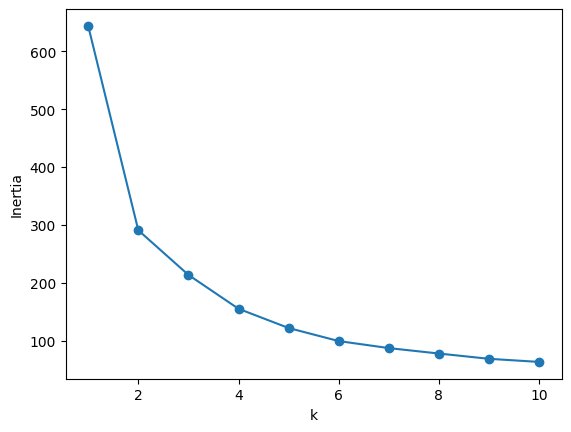

In [64]:
from sklearn.cluster import KMeans

inertias = []
for k in range(1,11):
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    km.fit(rfm[cols])
    inertias.append(km.inertia_)

plt.plot(range(1,11), inertias, marker =  'o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()


optimal value of k = 4

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm[cols])

In [66]:
rfm.sample(5)

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
16400.0,0.669234,0.000000,0.505711,3
15596.0,0.682379,0.544743,0.642481,2
14570.0,0.924272,0.279105,0.473680,3
15625.0,0.688712,0.488960,0.649722,2
17588.0,0.680234,0.409056,0.631894,2


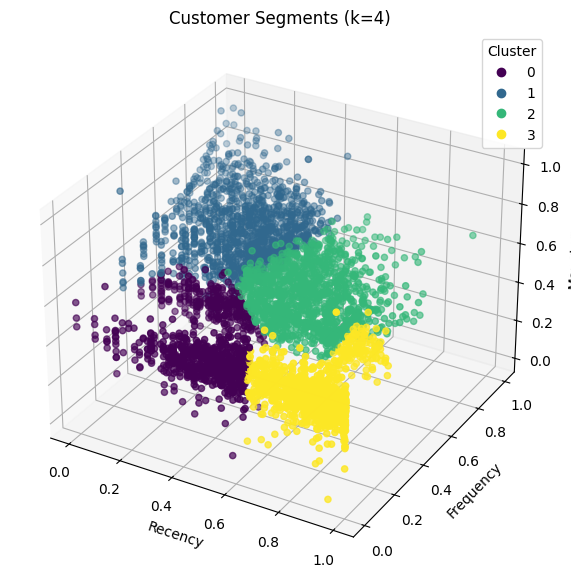

In [67]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'],
                      c=rfm['Cluster'], cmap='viridis')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title('Customer Segments (k=4)')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

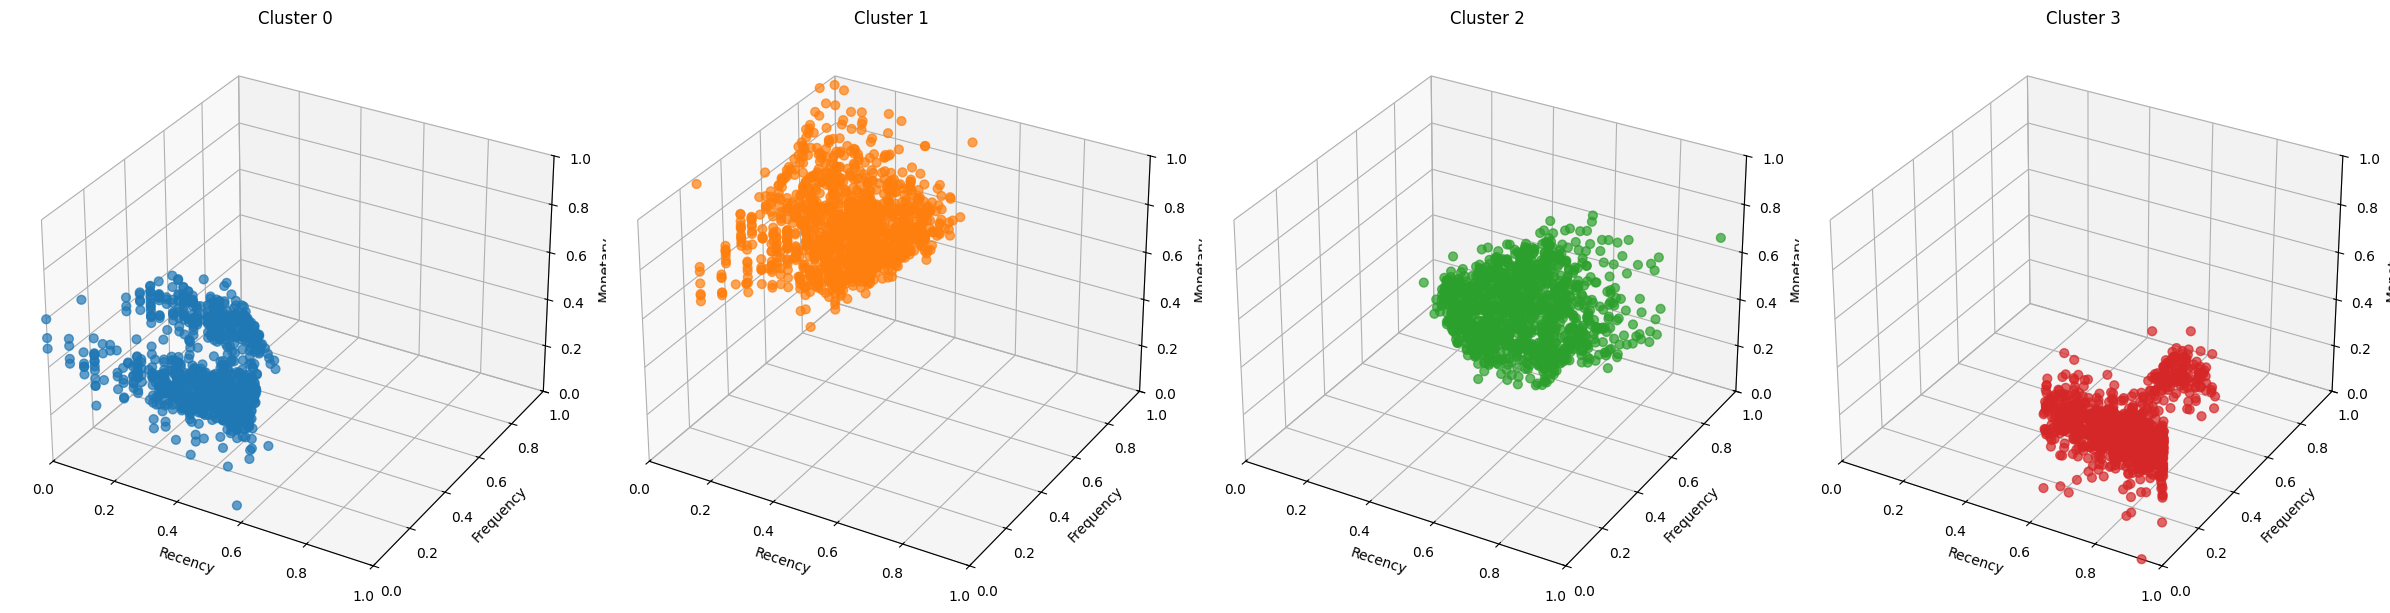

In [68]:

clusters = sorted(rfm['Cluster'].unique())
n = len(clusters)

fig = plt.figure(figsize=(6*n, 6))

xlim = (rfm['Recency'].min(), rfm['Recency'].max())
ylim = (rfm['Frequency'].min(), rfm['Frequency'].max())
zlim = (rfm['Monetary'].min(), rfm['Monetary'].max())

for i, cluster in enumerate(clusters):
    ax = fig.add_subplot(1, n, i+1, projection='3d')
    subset = rfm[rfm['Cluster'] == cluster]
    ax.scatter(subset['Recency'], subset['Frequency'], subset['Monetary'], s=40, alpha=0.7, color=f'C{i}')
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)
    ax.set_xlabel('Recency'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary')
    ax.set_title(f'Cluster {cluster}')

plt.tight_layout()
plt.show()

We have 4 different customer groups

Cluster 0: Average customers with moderate recency, frequency, and spend — no standout behavior in any dimension.

Cluster 1: Recently active, high-spending customers — engaged and valuable.

Cluster 2: Recently active customers with typical frequency and spend — the largest, most "average" segment.

Cluster 3: Lapsed customers with longer time since last purchase and lower engagement — at-risk of churn.